# Net Gamma Exposure (GEX) Calculator
### How The Markets Work (youtube.com/@HowTheMarketsWork) — Episode 001: Roaring Kitty vs Wall Street

**Run it:** Python 3 with `numpy`, `scipy` and `matplotlib` (`pip install numpy scipy matplotlib`), then run all cells. The sample chain is illustrative, not live market data.

This notebook implements the quantitative framework for calculating **Dealer Net Gamma Exposure (GEX)** across an options strike chain.

---

### Mathematical Framework

In modern options markets, designated market makers hedge directional delta exposure dynamically to remain **delta-neutral**:

$$\Delta_{\text{portfolio}} = \Delta_{\text{options}} + S_{\text{shares}} = 0$$

Because **Gamma** ($\Gamma = \frac{\partial \Delta}{\partial S}$) measures the rate of delta change, dealer inventory hedging varies with spot price movements:

- **Positive GEX Regime (Dealers Long Gamma):** Dealers buy as spot drops and sell as spot rises, dampening market volatility.
- **Negative GEX Regime (Dealers Short Gamma):** Dealers sell as spot drops and buy as spot rises, creating reflexive feedback loops.

### Dollar GEX Formula

For each strike $K$, Dollar GEX measures the dollar value of underlying shares dealers must trade per 1% change in spot price $S$:

$$\text{Call GEX}_K = \Gamma_K \times \text{OI}_{\text{call}} \times 100 \times S \times (0.01 \times S)$$
$$\text{Put GEX}_K = -\Gamma_K \times \text{OI}_{\text{put}} \times 100 \times S \times (0.01 \times S)$$
$$\text{Net GEX}_K = \text{Call GEX}_K + \text{Put GEX}_K$$

In [1]:
# 1. Core Imports & Aesthetics
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Visual Theme (Dark Institutional Charcoal)
BACKGROUND_COLOR = "#0B0E14"
SURFACE_COLOR = "#161B22"
TEXT_COLOR = "#F0F6FC"
MUTED_TEXT = "#8B949E"
GRID_COLOR = "#30363D"
CALL_COLOR = "#00E599"    # Neon Green (Long Gamma from Calls)
PUT_COLOR = "#FF7B72"     # Red (Short Gamma from Puts)
NET_COLOR = "#58A6FF"     # Cyan (Net GEX Profile)

plt.rcParams.update({
    "figure.facecolor": BACKGROUND_COLOR,
    "axes.facecolor": SURFACE_COLOR,
    "text.color": TEXT_COLOR,
    "axes.labelcolor": TEXT_COLOR,
    "xtick.color": MUTED_TEXT,
    "ytick.color": MUTED_TEXT,
    "grid.color": GRID_COLOR,
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "font.family": "sans-serif"
})
print("Environment initialized successfully.")

In [2]:
# 2. Black-Scholes Analytical Gamma
def black_scholes_gamma(S, K, r, sigma, T):
    """
    Calculate standard Black-Scholes Gamma (identical for Calls and Puts).
    
    Parameters:
        S (float): Current underlying spot price
        K (array-like): Strike prices
        r (float): Risk-free interest rate (annualized)
        sigma (float): Implied volatility (annualized)
        T (float): Time to maturity in years (e.g. 14 / 365)
    """
    if T <= 0 or sigma <= 0:
        return np.zeros_like(K, dtype=float)
    
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    return gamma

In [3]:
# 3. GEX Computation Engine
def calculate_gex(spot_price, strikes, call_oi, put_oi, iv, r=0.05, t_days=14):
    """
    Calculate Dollar Gamma Exposure per strike.
    Dollar GEX represents the dollar amount of underlying shares dealers must buy/sell
    for a 1% change in spot price.
    Sign convention (an assumption, the common one in GEX work): dealers are LONG the calls and
    SHORT the puts that customers trade, so call gamma counts positive and put gamma negative.
    Real dealer positioning is not public; a different assumption changes the sign.
    """
    T = t_days / 365.0
    gammas = black_scholes_gamma(spot_price, strikes, r, iv, T)
    
    # 1 option contract = 100 shares
    contract_multiplier = 100
    one_percent_move = spot_price * 0.01
    
    call_gex = gammas * call_oi * contract_multiplier * spot_price * one_percent_move
    put_gex = -gammas * put_oi * contract_multiplier * spot_price * one_percent_move
    net_gex = call_gex + put_gex
    
    return call_gex, put_gex, net_gex

In [4]:
# 4. Sample Options Chain & Execution
spot = 100.0
strikes = np.arange(80, 122, 2)

# Realistic open interest distribution around $100 strike
call_oi = np.array([500, 800, 1200, 2500, 4200, 7800, 15000, 28000, 19000, 12000, 8000, 5000, 3000, 1500, 800, 400, 200, 100, 50, 20, 10])
put_oi = np.array([20, 50, 120, 400, 1100, 2800, 6500, 14000, 22000, 16000, 9000, 4500, 2100, 900, 400, 150, 80, 30, 10, 5, 2])
iv = 0.35  # 35% annualized volatility

call_gex, put_gex, net_gex = calculate_gex(spot, strikes, call_oi, put_oi, iv)

# Convert to Millions of Dollars
call_gex_m = call_gex / 1e6
put_gex_m = put_gex / 1e6
net_gex_m = net_gex / 1e6
total_net_gex_m = np.sum(net_gex_m)

print(f"Options Chain Loaded:")
print(f"Spot Price: ${spot:.2f}")
print(f"Strikes evaluated: {len(strikes)} strikes (${strikes[0]} to ${strikes[-1]})")
print(f"Total Call OI: {np.sum(call_oi):,} contracts")
print(f"Total Put OI: {np.sum(put_oi):,} contracts")
print(f"Total Net Dollar GEX: ${total_net_gex_m:+.2f}M per 1% move")
print(f"Current Regime: {'POSITIVE (Volatility Dampening)' if total_net_gex_m > 0 else 'NEGATIVE (Volatility Amplifying)'}")

Options Chain Loaded:
Spot Price: $100.00
Strikes evaluated: 21 strikes ($80 to $120)
Total Call OI: 110,680 contracts
Total Put OI: 73,317 contracts
Total Net Dollar GEX: $+5.56M per 1% move
Current Regime: POSITIVE (Volatility Dampening)


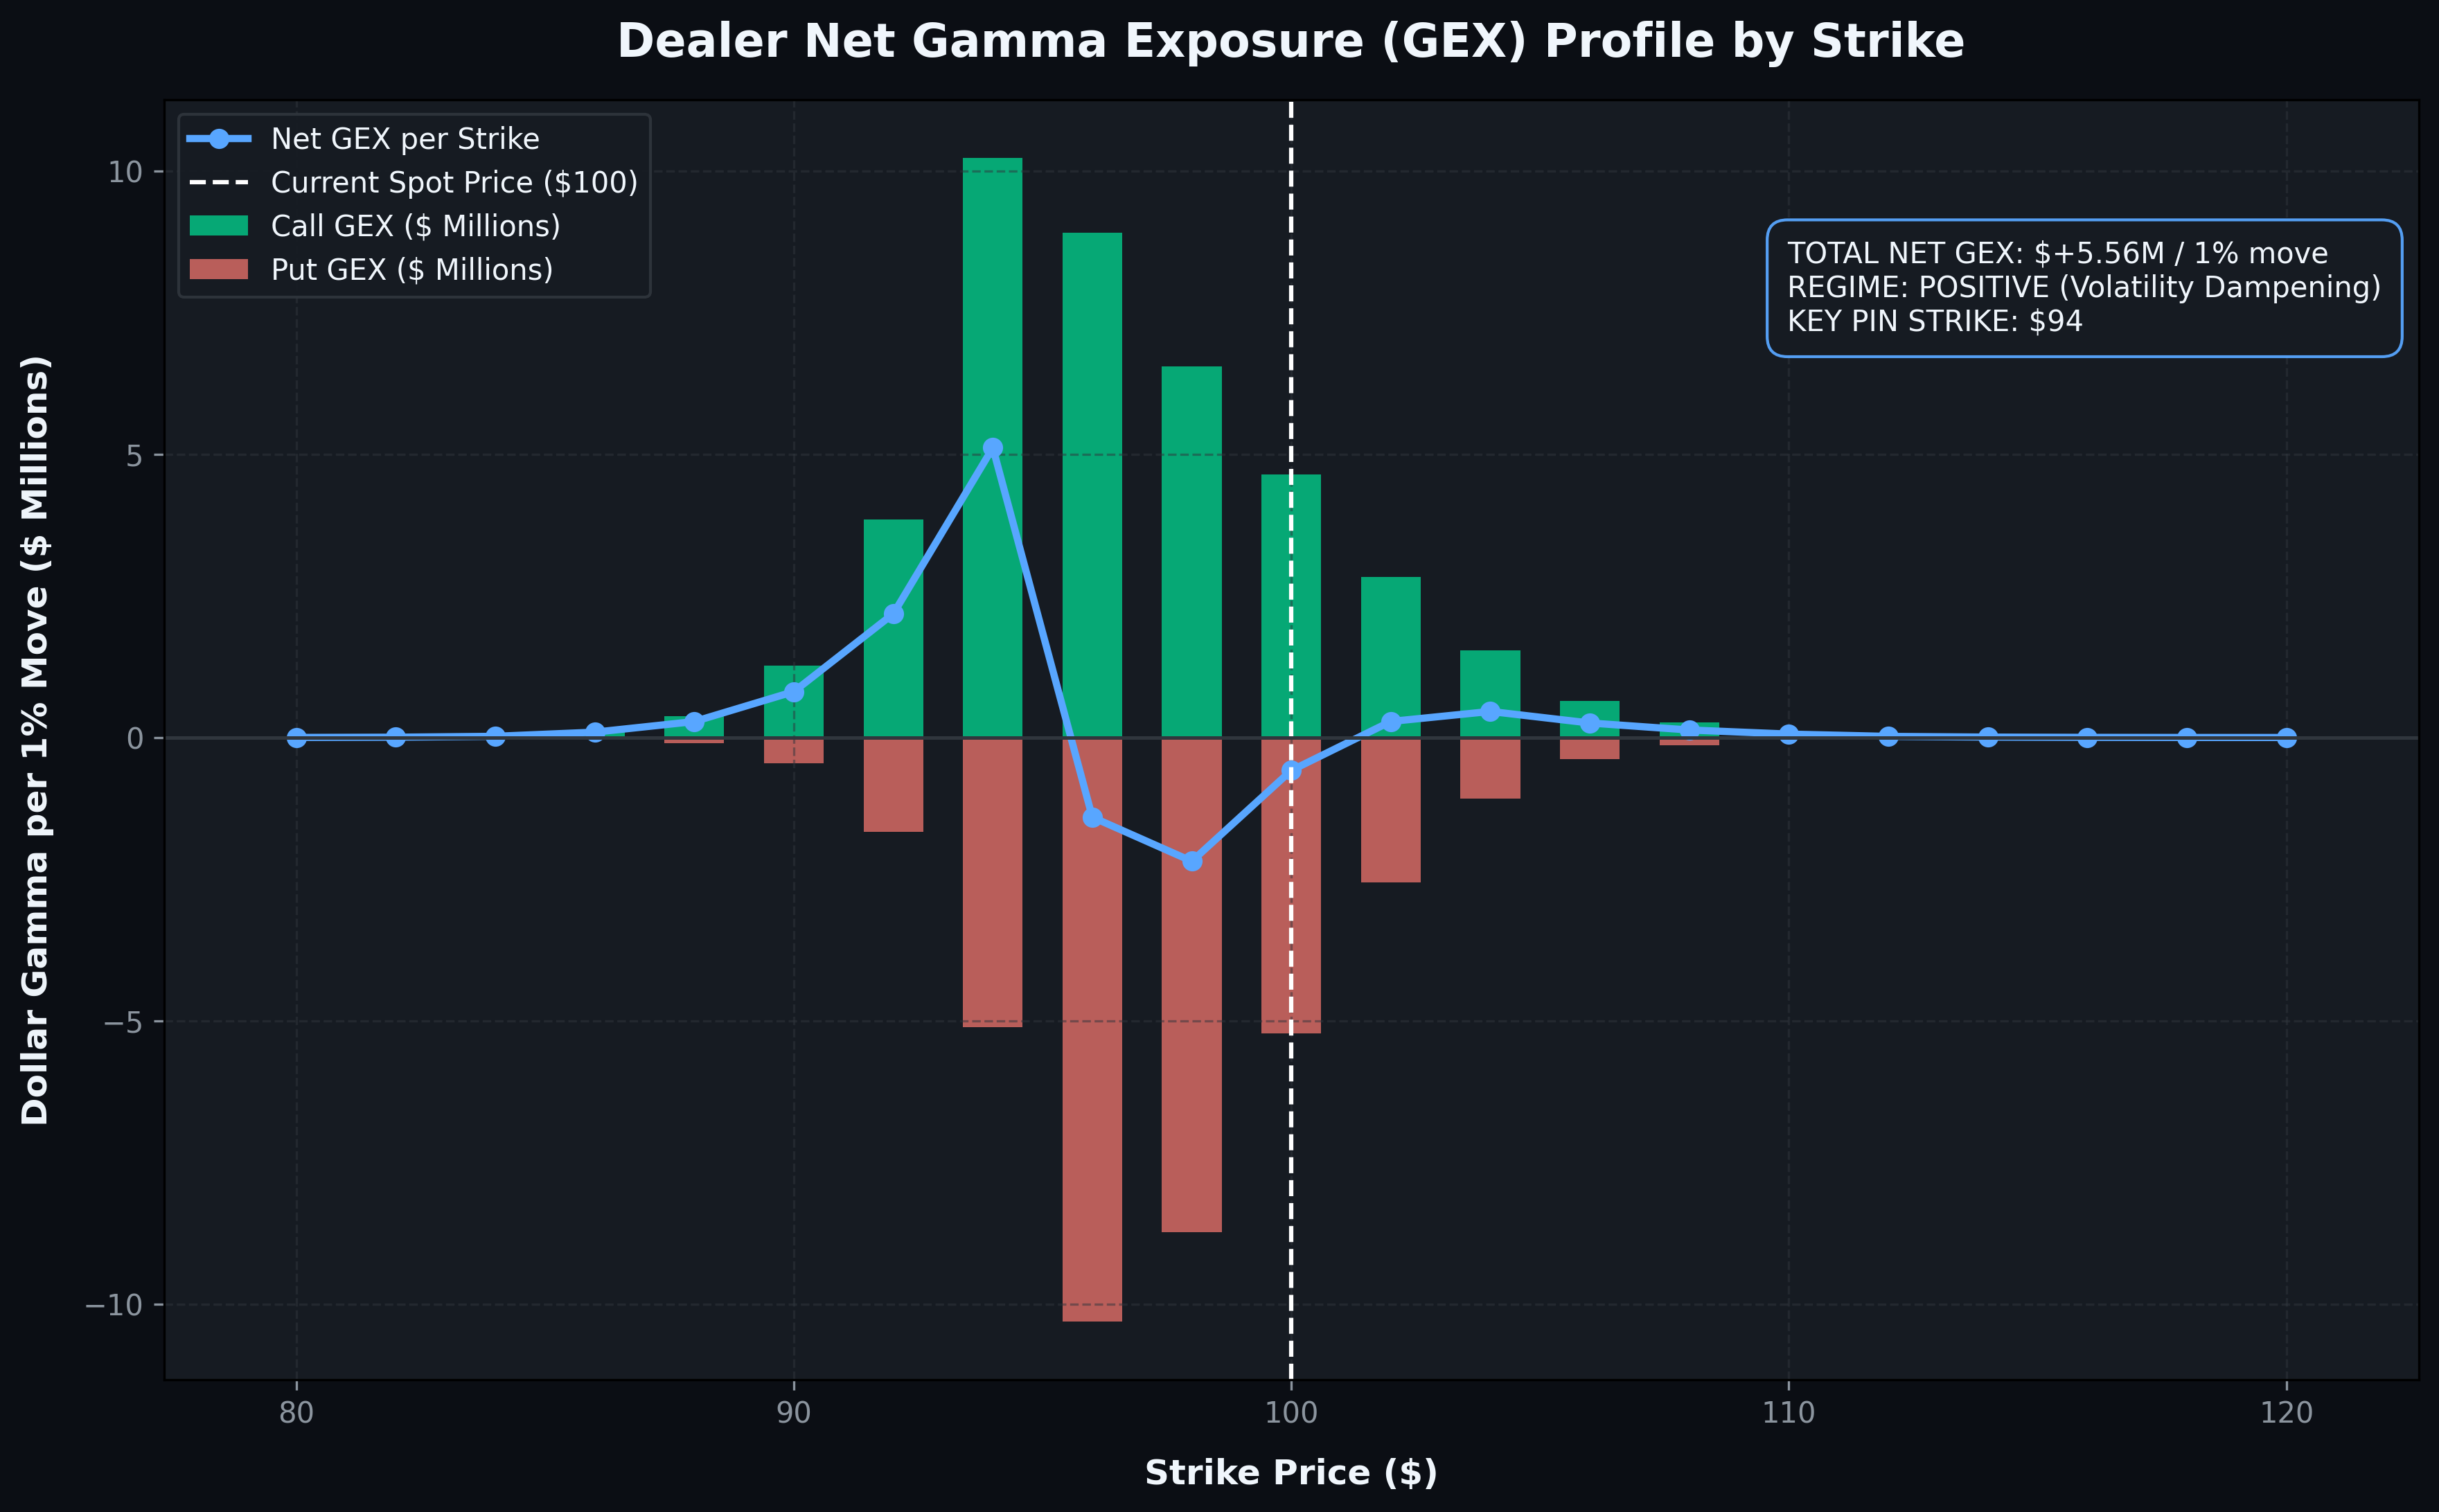

In [5]:
# 5. Publication-Grade GEX Profile Visualization
fig, ax = plt.subplots(figsize=(14, 8), dpi=300)

bar_width = 1.2
ax.bar(strikes, call_gex_m, width=bar_width, color=CALL_COLOR, alpha=0.75, label="Call GEX ($ Millions)")
ax.bar(strikes, put_gex_m, width=bar_width, color=PUT_COLOR, alpha=0.75, label="Put GEX ($ Millions)")
ax.plot(strikes, net_gex_m, color=NET_COLOR, marker="o", linewidth=2.5, label="Net GEX per Strike")

ax.axvline(x=spot, color="#FFFFFF", linestyle="--", linewidth=1.5, label=f"Current Spot Price (${spot:.0f})")
ax.axhline(y=0, color=GRID_COLOR, linestyle="-", linewidth=1.2)

ax.set_title("Dealer Net Gamma Exposure (GEX) Profile by Strike", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Strike Price ($)", fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylabel("Dollar Gamma per 1% Move ($ Millions)", fontsize=12, fontweight="bold", labelpad=10)
ax.legend(loc="upper left", framealpha=0.9, facecolor=SURFACE_COLOR, edgecolor=GRID_COLOR)
ax.grid(True)

pin_strike = strikes[np.argmax(call_gex_m)]
summary_text = (
    f"TOTAL NET GEX: ${total_net_gex_m:+.2f}M / 1% move\n"
    f"REGIME: {'POSITIVE (Volatility Dampening)' if total_net_gex_m > 0 else 'NEGATIVE (Volatility Amplifying)'}\n"
    f"KEY PIN STRIKE: ${pin_strike:.0f}"
)
ax.text(0.70, 0.80, summary_text, transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle="round,pad=0.7", facecolor=SURFACE_COLOR, edgecolor=NET_COLOR, alpha=0.95))

plt.tight_layout()
plt.show()

---
### Key Takeaways for Market Microstructure Analysis

1. **Largest positive net GEX at $94:** with this sample chain, call open interest peaks at $94 and net GEX there is about +$5.1M per 1% move, so dealer hedging leans against moves near that strike. Just above it ($96-$100) net GEX turns negative, where hedging adds to moves.
2. **Zero-Gamma Flip:** When spot falls into the negative put-dominated regime, dealer hedging shifts from mean-reverting to trend-amplifying.
3. **Educational Disclosure:** This model is educational and does not constitute investment advice.